<a href="https://colab.research.google.com/github/Grecia329/EcuacionesDiferencialesParciales-/blob/main/Copia_de_OC_S2_2026_MTI_Escalonada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo de distribucion escalonada con el Método de la Función Inversa

**Oliver Cuate**

*05 de marzo de 2026*

Los datos ficticios inventados en clase se comportan de la siguiente manera.

**NOTA:** por simplicidad, para generar el histograma se repite un valor dentro del invervalo deseado (el de enmedio) el número de veces que queremos, en la práctica hay que obtener la distribución a partir de datos reales.

[]

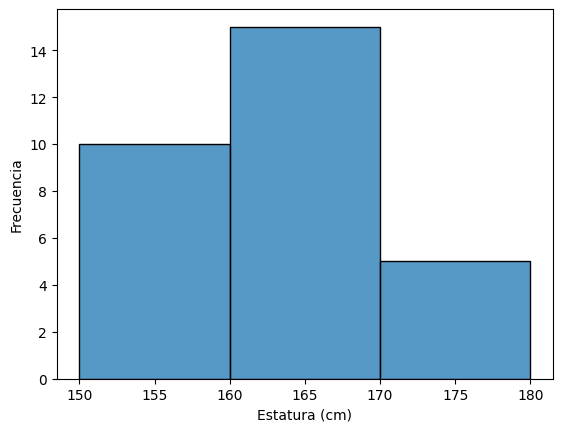

In [ ]:
import numpy as np
import seaborn as sns

datos = np.array(10*[155]+15*[165]+5*[175])

p = sns.histplot(datos,bins=[150,160,170,180])
p.set(xlabel='Estatura (cm)', ylabel ='Frecuencia')
p.plot()

## Obteniendo f(x) y F(x)

Para generar la función de distribución solamente hay que normalizar el área producida por el histograma de los datos (la suma del área de todos los rectángulos debe ser uno) es decir::

$$ A =  A_1 + A_2 + A_3 = 10 (160-150) + 15 (170-160) + 5 (180-170) = 100 + 150 + 50 = 300 $$

Con lo que se obtienen las probabilidades:

$p_1 = \dfrac{10}{300} = \dfrac{1}{30}, \; p_2 = \dfrac{15}{300} = \dfrac{1}{20}, \; p_3 = \dfrac{5}{300} = \dfrac{1}{60}$


### Función de densidad f(x)

Al final, la función de densidad queda definida de la siguiente manera:
$$ f(x) = \left\lbrace \begin{array}{cl}
\frac{1}{30}, & \mbox{ si } 150 \leq x < 160, \\
\frac{1}{20}, & \mbox{ si } 160 \leq x < 170, \\
\frac{1}{60}, & \mbox{ si } 170 \leq x \leq 180,
\end{array} \right. $$

Observa que $f(x) \geq 0\; ∀ \, x\in[150,180]$, y que $\displaystyle \int_{150}^{180}{f(x) \, dx} = 1$.

### Función de distribución acumulada F(x)

La primera parte es simplemente calcular la probabilidad acumulada para el "primer escalón":

$\displaystyle \int_{150}^{x}{ f(y) \, dy} = \int_{150}^{x}{ \dfrac{1}{30} \, dy} = \dfrac{1}{30}(x-150) $.

Posteriormente, para la acumulada del "segundo escalón", procedemos de forma análoga sin olvidarnos de sumar la contribución que ya hemos calculado. Es decir:

$\displaystyle \dfrac{1}{30}(160-150) + \int_{160}^{x}{ f(y) \, dy} = \dfrac{1}{3} + \int_{160}^{x}{ \dfrac{1}{20} \, dy} = \dfrac{1}{3} + \dfrac{(x-160)}{20} $.

Se hace lo mismo para el tercer y último escalón:

$\displaystyle \dfrac{1}{3} + \dfrac{(170-160)}{20} + \int_{170}^{x}{ f(y) \, dy} = \dfrac{1}{3} + \dfrac{1}{2} + \int_{170}^{x}{ \dfrac{1}{60} \, dy} = \dfrac{5}{6} + \dfrac{(x-170)}{60} $.

Según los cálculos hechos en clase, la función de distribución acumulada es:
$$ F(x) = \left\lbrace \begin{array}{ll}
\frac{1}{30} (x-150), & \mbox{ si } 150 \leq x < 160, \\
\frac{1}{3} + \frac{1}{20}(x-160), & \mbox{ si } 160 \leq x < 170, \\
\frac{5}{6} + \frac{1}{60}(x-170), & \mbox{ si } 170 \leq x < 180. \\
\end{array} \right. $$

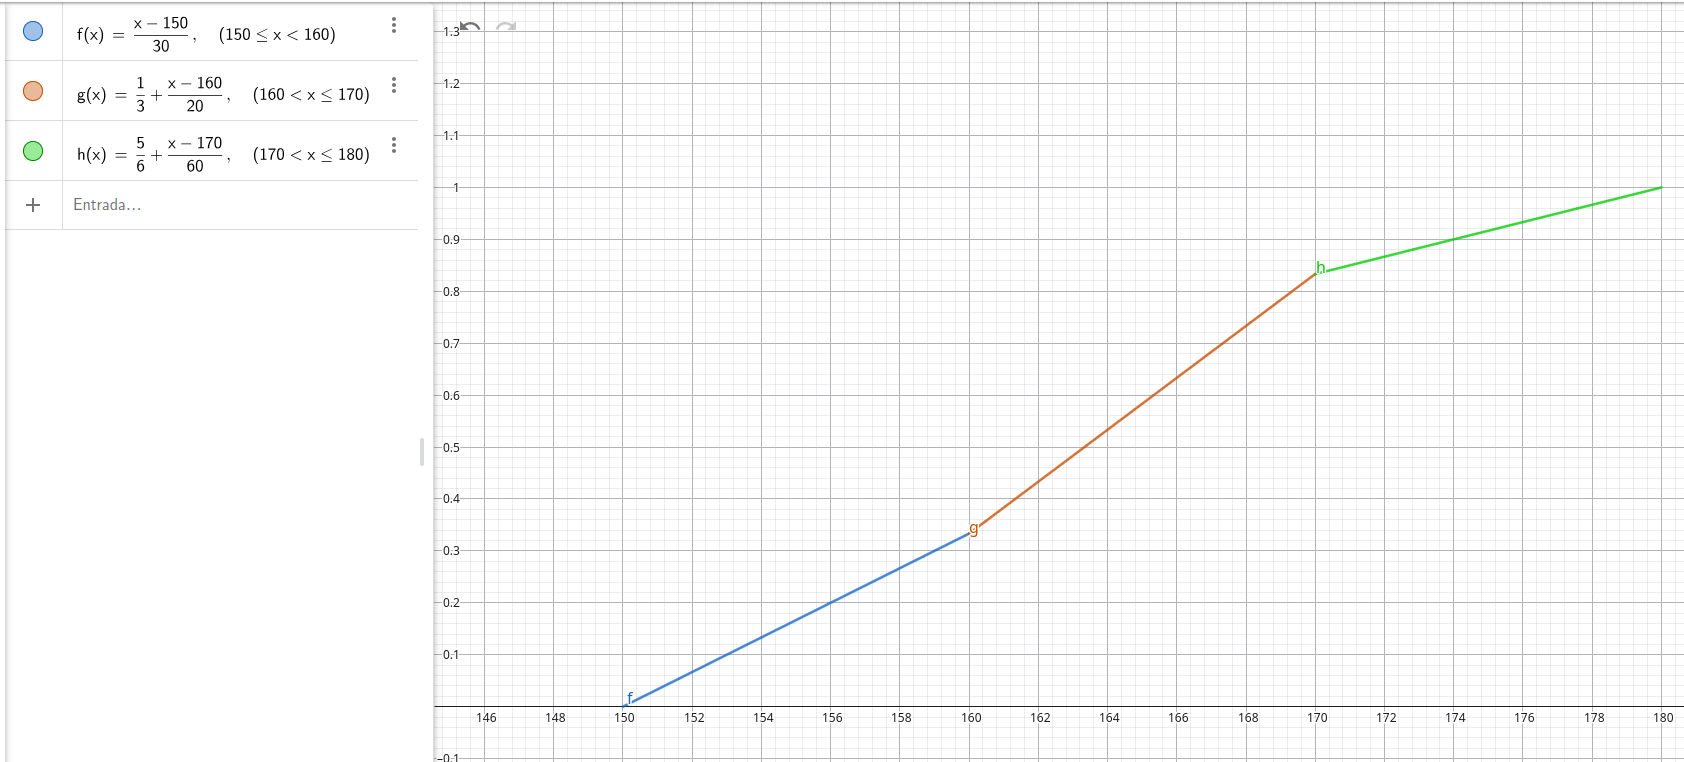

## Transformada Inversa

De igual forma, según lo hecho en clase, para usar el método de la transformada inversa hay que considerar $u = F(x)$, con $u \sim \mathcal{U}(0,1)$, para otener muestras de $x \sim F(x)$. Es decir:

$$ x = F^{-1}(u) = \left\lbrace \begin{array}{ll}
150 + 30 u, & \mbox{ si } 0 \leq u < \frac{1}{3}, \\
160 + 20 \left( u - \frac{1}{3} \right), & \mbox{ si } \frac{1}{3} \leq u < \frac{5}{6}, \\
170 + 60 \left( u - \frac{5}{6} \right), & \mbox{ si } \frac{5}{6} \leq u \leq 1.
\end{array} \right. $$


## Simulación

El programa que hace una simulación de $n$ personas con la misma distribución que la obtenida por sus datos se muestra a continuación:

In [ ]:
# Definimos la función de la transformada inversa
import random

def f_inv():
  u = random.random()
  if u < 1/3:
    x = 150 + u*30
  elif u < 5/6:
    x = 160 + 20*(u-1/3)
  else:
    x = 170 + 60*(u-5/6)

  return x

[]

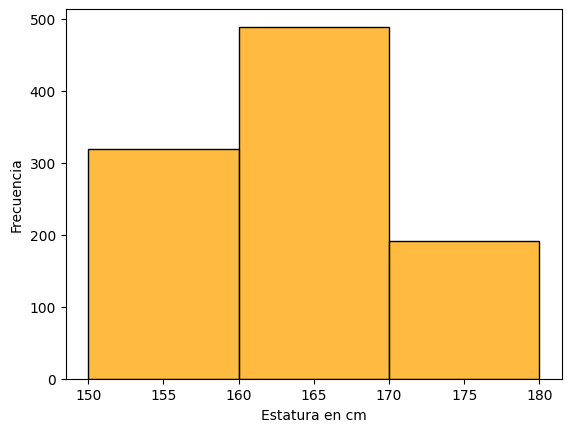

In [ ]:
# Genereamos n muestras y graficamos el histograma resultante
n = 1000   # tamaño de la muestra
M = []      # muestra

for i in range(n):
  M.append(f_inv())

p = sns.histplot(M,bins=3,color='orange')
p.set(xlabel='Estatura en cm', ylabel ='Frecuencia')
p.plot()